In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATv2Conv, GCNConv
from torch_geometric.nn.norm import LayerNorm
from torch_geometric.loader import DataLoader

In [3]:
# load the saved data
checkpoint = torch.load("../datasets/processed/metr_la/metr_la.pt")

train = checkpoint["train"]
val   = checkpoint["val"]
test  = checkpoint["test"]
mean  = checkpoint["mean"]
std   = checkpoint["std"]

In [4]:
# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
window_size  = 12
horizon      = 12
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size   = 32
in_feats     = window_size
hidden_feats = 64
out_feats    = horizon
num_layers   = 3
heads        = 4             # hidden_feats must be divisible by heads
dropout      = 0.3
lr           = 1e-3
epochs       = 5
print_every  = 100

In [5]:
# ─────────────────────────────────────────
# DATALOADERS
# ─────────────────────────────────────────

train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test,  batch_size=batch_size, shuffle=False)

# inspect one batch
batch = next(iter(train_loader))
print(batch)
print(f"x          : {batch.x.shape}")           # [325*32, 12]
print(f"edge_index : {batch.edge_index.shape}")  # [2, 2369*32]
print(f"edge_attr  : {batch.edge_attr.shape}")   # [2369*32, 1]
print(f"y          : {batch.y.shape}")           # [325*32, 12]
print(f"batch vec  : {batch.batch.shape}")       # [325*32] — which graph each node belongs to

DataBatch(x=[6624, 12], edge_index=[2, 48480], edge_attr=[48480, 1], y=[6624, 12], batch=[6624], ptr=[33])
x          : torch.Size([6624, 12])
edge_index : torch.Size([2, 48480])
edge_attr  : torch.Size([48480, 1])
y          : torch.Size([6624, 12])
batch vec  : torch.Size([6624])


In [6]:
# ---------------------------
# 1️⃣ Define a simple GCN model
# ---------------------------
class GCNBaseline(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden_feats)
        self.conv2 = GCNConv(hidden_feats, hidden_feats)
        self.fc = nn.Linear(hidden_feats, out_feats)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        
        # edge_attr must be shape [num_edges]
        # edge_weight = None
        edge_weight = edge_attr.squeeze() if edge_attr is not None else None
     
        x = F.relu(self.conv1(x, edge_index, edge_weight=edge_weight))
        x = F.relu(self.conv2(x, edge_index, edge_weight=edge_weight))
        x = self.fc(x)
        return x

In [16]:
class GraphSage(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers=3, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.hidden_feats = hidden_feats

        # Input layer
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.res_projs = nn.ModuleList()  # For residual projections

        # First layer
        self.convs.append(SAGEConv(in_feats, hidden_feats))
        self.norms.append(LayerNorm(hidden_feats))
        self.res_projs.append(nn.Linear(in_feats, hidden_feats))  # project input to hidden_feats

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_feats, hidden_feats))
            self.norms.append(LayerNorm(hidden_feats))
            self.res_projs.append(nn.Identity())  # hidden_feats → hidden_feats, identity

        # Output layer
        self.convs.append(SAGEConv(hidden_feats, hidden_feats))
        self.norms.append(LayerNorm(hidden_feats))
        self.res_projs.append(nn.Identity())

        # Final fully connected layer to predict horizon
        self.fc = nn.Linear(hidden_feats, out_feats)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        # SAGEConv does not support edge_weight
        # edge_weight = edge_attr.squeeze() if edge_attr is not None else None

        for i in range(self.num_layers):
            residual = self.res_projs[i](x)  # project residual to match hidden_feats
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual

        x = self.fc(x)
        return x

In [5]:
class TemporalBlock(nn.Module):
    """GRU-based temporal encoder — learns patterns across the input window."""
    def __init__(self, in_feats, hidden_feats, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = 1,
            hidden_size = hidden_feats,
            num_layers  = 2,
            batch_first = True,
            dropout     = dropout,
        )

    def forward(self, x):
        # x : [N, window_size]
        x = x.unsqueeze(-1)          # [N, window_size, 1]
        _, h = self.gru(x)           # h : [2, N, hidden]
        return h[-1]                 # [N, hidden]


class SpatialBlock(nn.Module):
    """GATv2 spatial layer — uses edge_index AND edge_attr as input to attention."""
    def __init__(self, hidden_feats, heads, dropout):
        super().__init__()
        assert hidden_feats % heads == 0, "hidden_feats must be divisible by heads"
        self.conv = GATv2Conv(
            in_channels       = hidden_feats,
            out_channels      = hidden_feats // heads,
            heads             = heads,
            edge_dim          = 1,        # edge_attr has 1 feature (Gaussian weight)
            dropout           = dropout,
            concat            = True,     # output = heads * (hidden // heads) = hidden
            add_self_loops    = False,    # already in adj_mx
        )
        self.norm    = LayerNorm(hidden_feats)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_attr):
        residual = x
        x = self.conv(x, edge_index, edge_attr=edge_attr)
        x = self.norm(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x + residual


class SpatioTemporalGNN(nn.Module):
    """
    Architecture:
        1. TemporalBlock  — GRU encodes time window → node embedding
        2. SpatialBlocks  — stacked GATv2 layers propagate spatial context
        3. FC head        — projects to forecast horizon

    Inputs (from PyG batch):
        data.x          : [N, window_size]
        data.edge_index : [2, E]
        data.edge_attr  : [E, 1]

    Output:
        [N, horizon]
    """
    def __init__(
        self,
        in_feats     : int,
        hidden_feats : int,
        out_feats    : int,
        num_layers   : int = 3,
        heads        : int = 4,
        dropout      : float = 0.3,
    ):
        super().__init__()

        # temporal encoder
        self.temporal = TemporalBlock(in_feats, hidden_feats, dropout)

        # spatial layers
        self.spatial = nn.ModuleList([
            SpatialBlock(hidden_feats, heads, dropout)
            for _ in range(num_layers)
        ])

        # output
        self.fc = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_feats, out_feats),
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # 1. temporal encoding
        x = self.temporal(x)                              # [N, hidden]

        # 2. spatial propagation
        for layer in self.spatial:
            x = layer(x, edge_index, edge_attr)           # [N, hidden]

        # 3. predict
        return self.fc(x)                                 # [N, horizon]

In [11]:
def train(model, train_loader, val_loader, optimizer, criterion, device,
          epochs, print_every=100, scheduler=None):

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch    = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # ── train ──
        model.train()
        total_loss   = 0.0
        running_loss = 0.0

        for step, batch in enumerate(train_loader, 1):
            batch  = batch.to(device)
            optimizer.zero_grad()
            loss   = criterion(model(batch), batch.y)
            loss.backward()
            optimizer.step()
            total_loss   += loss.item()
            running_loss += loss.item()
            if step % print_every == 0:
                print(f"  step {step:4d} | loss {running_loss / print_every:.4f}")
                running_loss = 0.0

        train_loss = total_loss / len(train_loader)

        # ── eval ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch     = batch.to(device)
                val_loss += criterion(model(batch), batch.y).item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            torch.save(model.state_dict(), "best_model.pt")

        print(f"  train loss : {train_loss:.4f}")
        print(f"  val loss   : {val_loss:.4f}  {'← best' if epoch == best_epoch else ''}")

    print(f"\nbest val loss : {best_val_loss:.4f} at epoch {best_epoch}")
    return train_losses, val_losses

In [12]:
model = GCNBaseline(in_feats, hidden_feats, out_feats).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ─────────────────────────────────────────
# 2️⃣ Train the model
# ─────────────────────────────────────────
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    print_every=print_every,
    scheduler=scheduler
)

Model parameters: 5,772

Epoch 1/5
  step  100 | loss 0.2638
  step  200 | loss 0.2353
  step  300 | loss 0.2314
  step  400 | loss 0.2350
  step  500 | loss 0.2345
  step  600 | loss 0.2352
  step  700 | loss 0.2251
  train loss : 0.2367
  val loss   : 0.2123  ← best

Epoch 2/5
  step  100 | loss 0.2347
  step  200 | loss 0.2320
  step  300 | loss 0.2281
  step  400 | loss 0.2297
  step  500 | loss 0.2287
  step  600 | loss 0.2300
  step  700 | loss 0.2259
  train loss : 0.2298
  val loss   : 0.2088  ← best

Epoch 3/5
  step  100 | loss 0.2243
  step  200 | loss 0.2346
  step  300 | loss 0.2252
  step  400 | loss 0.2263
  step  500 | loss 0.2267
  step  600 | loss 0.2290
  step  700 | loss 0.2280
  train loss : 0.2275
  val loss   : 0.2075  ← best

Epoch 4/5
  step  100 | loss 0.2267
  step  200 | loss 0.2290
  step  300 | loss 0.2236
  step  400 | loss 0.2256
  step  500 | loss 0.2266
  step  600 | loss 0.2326
  step  700 | loss 0.2227
  train loss : 0.2262
  val loss   : 0.2065  ← b

In [17]:
# Instantiate model
model = GraphSage(
    in_feats=in_feats,
    hidden_feats=hidden_feats,
    out_feats=out_feats,
    num_layers=num_layers,
    dropout=dropout
).to(device)

# Optimizer, criterion, scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ---------------------------
# 2️⃣ Train the model
# ---------------------------
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    print_every=print_every,
    scheduler=scheduler
)

Model parameters: 20,108

Epoch 1/5
  step  100 | loss 0.1900
  step  200 | loss 0.1269
  step  300 | loss 0.1163
  step  400 | loss 0.1136
  step  500 | loss 0.1102
  step  600 | loss 0.1095
  step  700 | loss 0.1086
  train loss : 0.1239
  val loss   : 0.1036  ← best

Epoch 2/5
  step  100 | loss 0.1106
  step  200 | loss 0.1095
  step  300 | loss 0.1065
  step  400 | loss 0.1067
  step  500 | loss 0.1070
  step  600 | loss 0.1078
  step  700 | loss 0.1063
  train loss : 0.1076
  val loss   : 0.0992  ← best

Epoch 3/5
  step  100 | loss 0.1072
  step  200 | loss 0.1058
  step  300 | loss 0.1054
  step  400 | loss 0.1059
  step  500 | loss 0.1077
  step  600 | loss 0.1046
  step  700 | loss 0.1035
  train loss : 0.1059
  val loss   : 0.0983  ← best

Epoch 4/5
  step  100 | loss 0.1057
  step  200 | loss 0.1064
  step  300 | loss 0.1063
  step  400 | loss 0.1048
  step  500 | loss 0.1021
  step  600 | loss 0.1044
  step  700 | loss 0.1055
  train loss : 0.1052
  val loss   : 0.0982  ← 

In [13]:
# ─────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────
# model     = SpatioTemporalGNN(in_feats, hidden_feats, out_feats, num_layers, heads, dropout).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
# criterion = nn.HuberLoss(delta=1.0)   # more robust to outliers than MSE
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

# train_losses, val_losses = train(
#     model, train_loader, val_loader,
#     optimizer, criterion, device,
#     epochs=epochs, print_every=print_every,
#     scheduler=scheduler,
# )

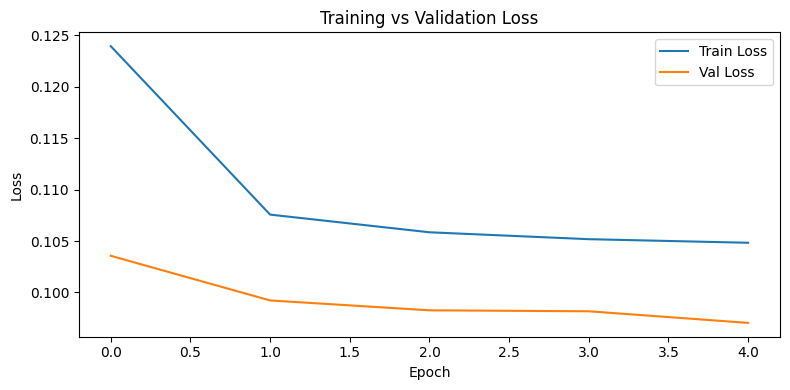

In [18]:
# ---------------------------
# PLOTTING LOSSES
# ---------------------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def test(model, test_loader, mean, std, device):
    all_preds, all_targets = [], []

    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out   = model(batch)
            all_preds.append(out.cpu())
            all_targets.append(batch.y.cpu())

    all_preds   = torch.cat(all_preds,   dim=0)   # [T*N, horizon]
    all_targets = torch.cat(all_targets, dim=0)   # [T*N, horizon]

    # denormalize
    all_preds_denorm   = all_preds   * std + mean
    all_targets_denorm = all_targets * std + mean

    # metrics
    mse  = torch.mean((all_preds_denorm - all_targets_denorm) ** 2)
    rmse = torch.sqrt(mse)
    mae  = torch.mean(torch.abs(all_preds_denorm - all_targets_denorm))

    print(f"rmse : {rmse:.4f}")
    print(f"mae  : {mae:.4f}")

    return all_preds_denorm, all_targets_denorm


preds, targets = test(model, test_loader, mean, std, device)

rmse : 6.8874
mae  : 3.5801
